In [2]:
import pandas as pd
import numpy as np
import os

# Project path
project_path = r'C:\Users\moham\Ecommerce_Customer_360_Analytics'

# Excel file path
file_path = os.path.join(
    project_path,
    '02_Cleaned_Data',
    'data_360.xlsx'
)

# Read data
df = pd.read_excel(file_path, sheet_name='Sheet1')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Shape: (118763, 25)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_delivered', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'product_weight_g', 'seller_city', 'seller_state', 'Product_category_name_english']

First 5 rows:
                           order_id                       customer_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
1  532ed5e14e24ae1f0d735b91524b98b9  4ef55bf80f711b372afebcb7c715344a   
2  7d19f4ef4d04461989632411b7e588b9  91a792fef70ecd8cc69d3c7feb3d12da   
3  c9ef97d2854afe64a3b4488bc2836af6  0a29abf475fb8039d2775913d6f0b6f0   
4  130898c0987d1801452a8ed92a670612  e6eecc5a77de221464d1c4eaff0a9b64   

  order_status order_purc

In [3]:
print(df.shape)

if df.empty:
    print("WARNING: DataFrame is empty. Check file path or sheet name.")
else:
    print("Data loaded successfully.")

(118763, 25)
Data loaded successfully.


In [4]:
# Check data types
print(df.dtypes)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)

print("\nMissing Values:")
print(missing[missing > 0])

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Unique orders
print("\nUnique orders:", df['order_id'].nunique())

# Unique customers
print("Unique customers:", df['customer_unique_id'].nunique())

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
is_delivered                             object
order_item_id                           float64
product_id                               object
seller_id                                object
price                                   float64
freight_value                           float64
customer_unique_id                       object
customer_city                            object
customer_state                           object
payment_type                             object
payment_installments                    float64
payment_value                           float64
review_score                            

In [5]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [6]:
df['delivery_delay'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days

In [7]:
order_df = (
    df.sort_values('order_purchase_timestamp')
      .drop_duplicates('order_id')
      .copy()
)

print("Order-level rows:", len(order_df))
print("Unique orders:", order_df['order_id'].nunique())

Order-level rows: 99441
Unique orders: 99441


In [8]:
order_df = (
    df.sort_values('order_purchase_timestamp')
      .drop_duplicates('order_id')
      .copy()
)

print("Order-level rows:", len(order_df))
print("Unique orders:", order_df['order_id'].nunique())

Order-level rows: 99441
Unique orders: 99441


In [9]:
customer_df = (
    order_df
    .groupby('customer_unique_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_revenue=('payment_value', 'sum'),
        last_purchase=('order_purchase_timestamp', 'max'),
        first_purchase=('order_purchase_timestamp', 'min')
    )
    .reset_index()
)

print(customer_df.head())

                 customer_unique_id  total_orders  total_revenue  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1         141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1          27.19   
2  0000f46a3911fa3c0805444483337064             1          86.22   
3  0000f6ccb0745a6a4b88665a16c9f078             1          43.62   
4  0004aac84e0df4da2b147fca70cf8255             1         196.89   

  last_purchase first_purchase  
0    2018-05-10     2018-05-10  
1    2018-05-07     2018-05-07  
2    2017-03-10     2017-03-10  
3    2017-10-12     2017-10-12  
4    2017-11-14     2017-11-14  


   order_month     revenue  orders  customers         aov     mom_growth
0      2016-09      252.24       4          4   63.060000            NaN
1      2016-10    58372.64     324        321  180.162469   23041.706311
2      2016-12       19.62       1          1   19.620000     -99.966388
3      2017-01   135785.28     800        765  169.731600  691975.840979
4      2017-02   285454.89    1780       1755  160.367916     110.225210
5      2017-03   440578.31    2682       2642  164.272301      54.342534
6      2017-04   406738.53    2404       2372  169.192400      -7.680764
7      2017-05   579061.72    3700       3625  156.503168      42.367068
8      2017-06   503328.51    3245       3180  155.108940     -13.078608
9      2017-07   579854.54    4026       3947  144.027457      15.203993
10     2017-08   660712.77    4331       4246  152.554322      13.944571
11     2017-09   715025.27    4285       4212  166.867041       8.220289
12     2017-10   767507.01    4631       4561  165.

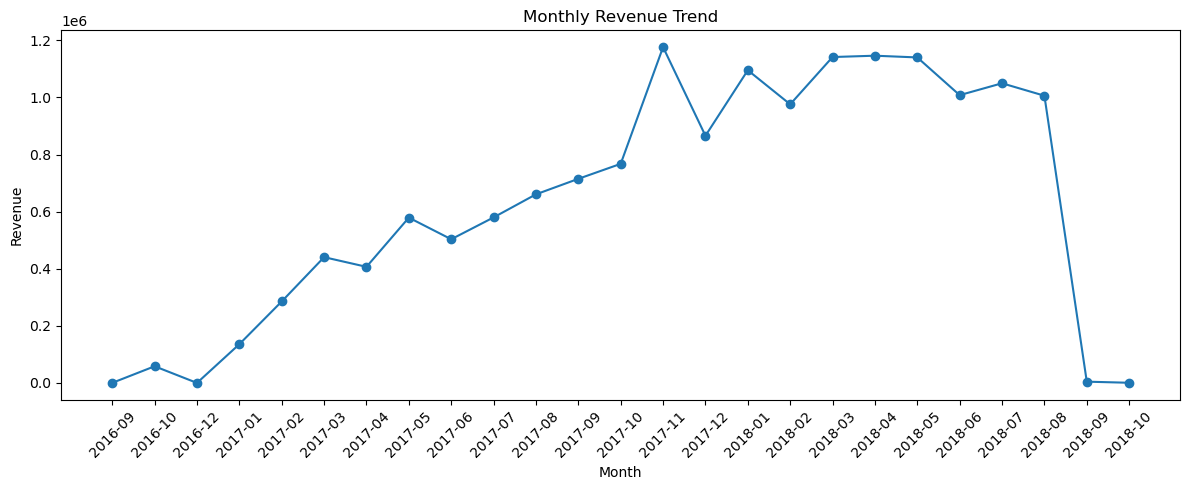

In [10]:
# BUSINESS PROBLEM 1:
# How does revenue, order volume, and customer count change month by month?

order_df['order_month'] = (
    order_df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

monthly_sales = (
    order_df
    .groupby('order_month')
    .agg(
        revenue=('payment_value', 'sum'),
        orders=('order_id', 'nunique'),
        customers=('customer_unique_id', 'nunique')
    )
    .reset_index()
)

monthly_sales['aov'] = (
    monthly_sales['revenue']
    / monthly_sales['orders']
)

monthly_sales['mom_growth'] = (
    monthly_sales['revenue'].pct_change() * 100
)

print(monthly_sales)

print("\nHighest revenue month:")
print(
    monthly_sales.loc[
        monthly_sales['revenue'].idxmax()
    ]
)

# A line chart is used because monthly revenue is a time-based trend.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['order_month'],
    monthly_sales['revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
# How dependent is the business on a small group of customers?

customer_revenue = (
    customer_df
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)

customer_revenue['cumulative_revenue'] = (
    customer_revenue['total_revenue'].cumsum()
)

total_revenue = customer_revenue['total_revenue'].sum()

customer_revenue['cumulative_percent'] = (
    customer_revenue['cumulative_revenue']
    / total_revenue * 100
)


print(customer_revenue.head(10))

                 customer_unique_id  total_orders  total_revenue  \
0  0a0a92112bd4c708ca5fde585afaa872             1       13664.08   
1  46450c74a0d8c5ca9395da1daac6c120             3        9553.02   
2  da122df9eeddfedc1dc1f5349a1a690c             2        7571.63   
3  763c8b1c9c68a0229c42c9fc6f662b93             1        7274.88   
4  dc4802a71eae9be1dd28f5d788ceb526             1        6929.31   
5  459bef486812aa25204be022145caa62             1        6922.21   
6  ff4159b92c40ebe40454e3e6a7c35ed6             1        6726.66   
7  4007669dec559734d6f53e029e360987             1        6081.54   
8  5d0a2980b292d049061542014e8960bf             1        4809.44   
9  eebb5dda148d3893cdaf5b5ca3040ccb             1        4764.34   

  last_purchase first_purchase  cumulative_revenue  cumulative_percent  
0    2017-09-29     2017-09-29            13664.08            0.086790  
1    2018-08-17     2018-07-24            23217.10            0.147468  
2    2017-04-01     2017-04-01  

In [12]:
customer_revenue = (
    customer_df
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)

customer_revenue['cumulative_revenue'] = (
    customer_revenue['total_revenue'].cumsum()
)

total_revenue = customer_revenue['total_revenue'].sum()

customer_revenue['cumulative_percent'] = (
    customer_revenue['cumulative_revenue']
    / total_revenue * 100
)


In [13]:
top_10_count = int(len(customer_revenue) * 0.10)

top_10_revenue = (
    customer_revenue
    .head(top_10_count)['total_revenue']
    .sum()
)

top_10_share = (
    top_10_revenue / total_revenue * 100
)

print("Top 10% customer revenue share:",
      round(top_10_share, 2), "%")

Top 10% customer revenue share: 38.65 %


In [14]:
customers_for_80 = (
    customer_revenue[
        customer_revenue['cumulative_percent'] >= 80
    ].index[0] + 1
)

print(
    "Customers needed for 80% revenue:",
    customers_for_80
)

print(
    "Percentage of customers:",
    round(
        customers_for_80 / len(customer_revenue) * 100,
        2
    ),
    "%"
)

Customers needed for 80% revenue: 46353
Percentage of customers: 48.24 %


In [15]:
# BUSINESS PROBLEM 3:
# Which customers are our most valuable customers based on
# Recency, Frequency, and Monetary value?

analysis_date = (
    order_df['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

rfm = (
    order_df
    .groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('payment_value', 'sum')
    )
    .reset_index()
)

rfm['recency'] = (
    analysis_date - rfm['recency']
).dt.days

rfm['r_rank'] = rfm['recency'].rank(method='first')
rfm['f_rank'] = rfm['frequency'].rank(method='first')
rfm['m_rank'] = rfm['monetary'].rank(method='first')

rfm['R'] = pd.qcut(
    rfm['r_rank'],
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm['F'] = pd.qcut(
    rfm['f_rank'],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm['M'] = pd.qcut(
    rfm['m_rank'],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm.drop(
    columns=['r_rank', 'f_rank', 'm_rank'],
    inplace=True
)

print(rfm.head(10))
print("Total customers:", len(rfm))

                 customer_unique_id  recency  frequency  monetary  R  F  M
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90  4  1  3
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19  4  1  1
2  0000f46a3911fa3c0805444483337064      587          1     86.22  1  1  2
3  0000f6ccb0745a6a4b88665a16c9f078      371          1     43.62  2  1  1
4  0004aac84e0df4da2b147fca70cf8255      338          1    196.89  2  1  4
5  0004bd2a26a76fe21f786e4fbd80607f      196          1    166.98  3  1  3
6  00050ab1314c0e55a6ca13cf7181fecf      181          1     35.38  3  1  1
7  00053a61a98854899e70ed204dd4bafe      232          1    419.18  3  1  4
8  0005e1862207bf6ccc02e4228effd9a0      593          1    150.12  1  1  3
9  0005ef4cd20d2893f0d9fbd94d3c0d97      220          1    129.76  3  1  3
Total customers: 96096


           segment  customers
0  Loyal Customers      29749
1          At-Risk      24045
2          Regular      17825
3        Cant Lose      11970
4        Champions       6308
5      Hibernating       6199


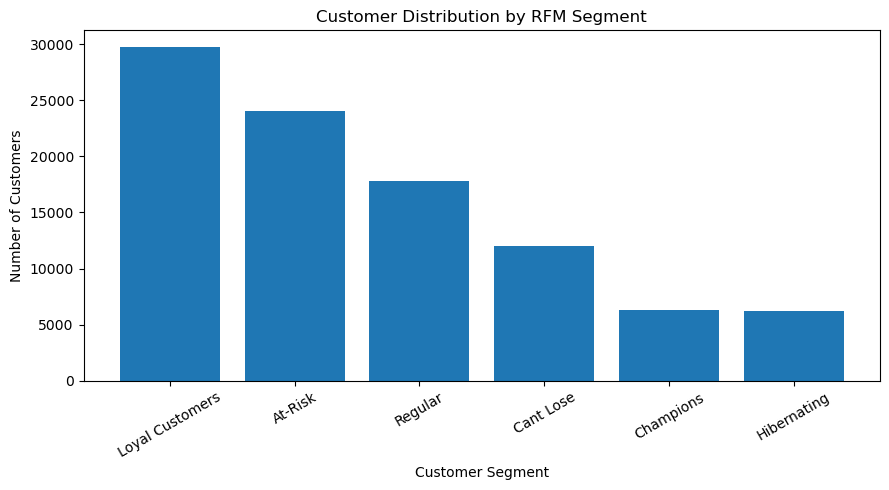

In [16]:
# BUSINESS PROBLEM 4:
# How can customers be divided into meaningful business segments
# for targeted marketing?

def get_segment(row):

    if row['R'] == 4 and row['F'] >= 3 and row['M'] >= 3:
        return 'Champions'

    elif row['R'] >= 3 and row['F'] >= 2:
        return 'Loyal Customers'

    elif row['R'] <= 2 and row['F'] >= 3 and row['M'] >= 3:
        return 'Cant Lose'

    elif row['R'] <= 2 and row['F'] >= 2:
        return 'At-Risk'

    elif row['R'] <= 2 and row['F'] <= 2 and row['M'] <= 2:
        return 'Hibernating'

    else:
        return 'Regular'


rfm['segment'] = rfm.apply(
    get_segment,
    axis=1
)

segment_count = (
    rfm['segment']
    .value_counts()
    .reset_index()
)

segment_count.columns = [
    'segment',
    'customers'
]

print(segment_count)

# This chart shows how the total customer base is distributed
# across different RFM segments.

plt.figure(figsize=(9, 5))

plt.bar(
    segment_count['segment'],
    segment_count['customers']
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [17]:
# BUSINESS PROBLEM 5:
# How many customers are churned and how much revenue is at risk?

# A customer with no purchase for more than 180 days
# is classified as churned for this analysis.

rfm['churn_flag'] = np.where(
    rfm['recency'] > 180,
    'Churned',
    'Active'
)

total_customers = len(rfm)

churned_customers = (
    rfm['churn_flag'] == 'Churned'
).sum()

churn_rate = (
    churned_customers / total_customers * 100
)

churn_revenue = (
    rfm.loc[
        rfm['churn_flag'] == 'Churned',
        'monetary'
    ].sum()
)

total_customer_revenue = rfm['monetary'].sum()

revenue_at_risk_percent = (
    churn_revenue
    / total_customer_revenue
    * 100
)

print("Total customers:", total_customers)
print("Churned customers:", churned_customers)
print("Churn rate:", round(churn_rate, 2), "%")
print("Churned customer revenue:", round(churn_revenue, 2))
print(
    "Revenue at risk:",
    round(revenue_at_risk_percent, 2),
    "%"
)

Total customers: 96096
Churned customers: 68398
Churn rate: 71.18 %
Churned customer revenue: 11071834.12
Revenue at risk: 70.32 %


In [18]:
# BUSINESS PROBLEM 6:
# How many customers are one-time buyers and how many are repeat customers?

one_time_customers = (
    customer_df['total_orders'] == 1
).sum()

repeat_customers = (
    customer_df['total_orders'] > 1
).sum()

repeat_rate = (
    repeat_customers
    / len(customer_df)
    * 100
)

average_orders = customer_df['total_orders'].mean()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)
print("Repeat customer rate:", round(repeat_rate, 2), "%")
print("Average orders per customer:", round(average_orders, 2))

One-time customers: 93099
Repeat customers: 2997
Repeat customer rate: 3.12 %
Average orders per customer: 1.03


Total revenue: 15743826.42
Total orders: 99441
Overall AOV: 158.32

AOV by customer segment:
           segment  customers     revenue     avg_aov  median_aov
0          At-Risk      24045  2640881.62  109.509011       72.99
1        Cant Lose      11970  3223267.44  252.397276      173.46
2        Champions       6308  1773865.30  257.259471      173.32
3      Hibernating       6199   383146.56   61.807801       61.11
4  Loyal Customers      29749  4267957.17  139.101736       88.90
5          Regular      17825  3454708.33  193.812529      136.37


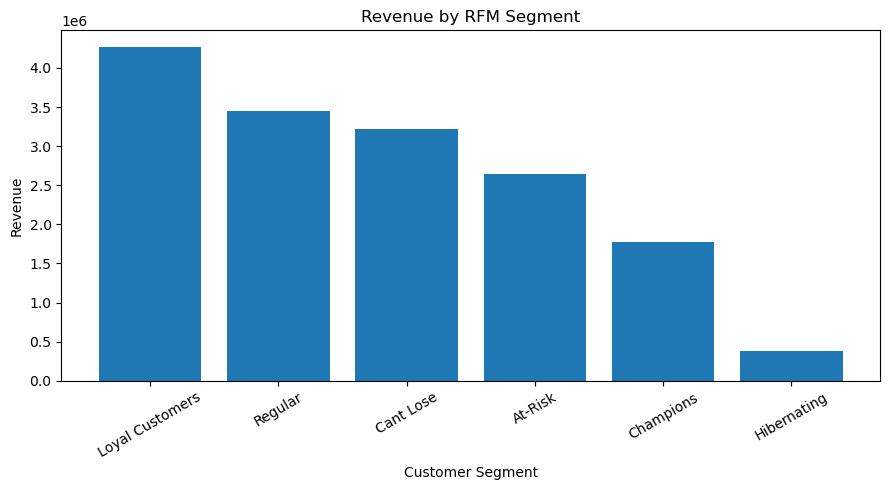

In [19]:
# BUSINESS PROBLEM 7:
# What is the average order value and how much does each
# customer segment contribute to revenue?

total_revenue = order_df['payment_value'].sum()

total_orders = order_df['order_id'].nunique()

aov = (
    total_revenue
    / total_orders
)

rfm['customer_aov'] = (
    rfm['monetary']
    / rfm['frequency']
)

segment_aov = (
    rfm
    .groupby('segment')
    .agg(
        customers=('customer_unique_id', 'count'),
        revenue=('monetary', 'sum'),
        avg_aov=('customer_aov', 'mean'),
        median_aov=('customer_aov', 'median')
    )
    .reset_index()
)

print("Total revenue:", round(total_revenue, 2))
print("Total orders:", total_orders)
print("Overall AOV:", round(aov, 2))

print("\nAOV by customer segment:")
print(segment_aov)

# This chart compares the business value generated by each
# customer segment.
segment_revenue_chart = (
    segment_aov
    .sort_values('revenue', ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    segment_revenue_chart['segment'],
    segment_revenue_chart['revenue']
)

plt.title('Revenue by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [20]:
# BUSINESS PROBLEM 8:
# Does late delivery affect customer satisfaction?

delivery_df = order_df[
    [
        'order_id',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'delivery_delay',
        'review_score'
    ]
].copy()

delivery_df = delivery_df.dropna(
    subset=['delivery_delay', 'review_score']
)

delivery_df['delivery_status'] = np.where(
    delivery_df['delivery_delay'] > 0,
    'Late',
    'On-Time'
)

delivery_summary = (
    delivery_df
    .groupby('delivery_status')
    .agg(
        orders=('order_id', 'nunique'),
        avg_review=('review_score', 'mean'),
        avg_delay=('delivery_delay', 'mean')
    )
    .reset_index()
)

late_orders = (
    delivery_df['delivery_status'] == 'Late'
).sum()

total_delivered_orders = len(delivery_df)

late_percentage = (
    late_orders
    / total_delivered_orders
    * 100
)

correlation = (
    delivery_df[
        ['delivery_delay', 'review_score']
    ]
    .corr()
    .loc['delivery_delay', 'review_score']
)

print(delivery_summary)
print("Late delivery percentage:", round(late_percentage, 2), "%")
print("Delivery delay vs review correlation:", round(correlation, 3))

  delivery_status  orders  avg_review  avg_delay
0            Late    6347    2.271467  10.519300
1         On-Time   89023    4.292554 -13.509228
Late delivery percentage: 6.66 %
Delivery delay vs review correlation: -0.267


In [21]:
# Delivery performance (order-level deduped)
delivery_df = order_df[[
    'order_id', 'delivery_delay', 'review_score'
]].dropna().copy()

late = delivery_df[delivery_df['delivery_delay'] > 0]
ontime = delivery_df[delivery_df['delivery_delay'] <= 0]

print("Total Orders:", len(delivery_df))
print("Late Orders:", len(late), f"({len(late)/len(delivery_df)*100:.2f}%)")
print("Avg Review (Late):", round(late['review_score'].mean(), 2))
print("Avg Review (On-Time):", round(ontime['review_score'].mean(), 2))


Total Orders: 95370
Late Orders: 6347 (6.66%)
Avg Review (Late): 2.27
Avg Review (On-Time): 4.29


      delay_bucket  orders  avg_review
0    1-5 Days Late    2711    2.990409
1  11-20 Days Late    1253    1.664804
2    20+ Days Late     759    1.769433
3   6-10 Days Late    1624    1.774015
4  Early / On-Time   89023    4.292554


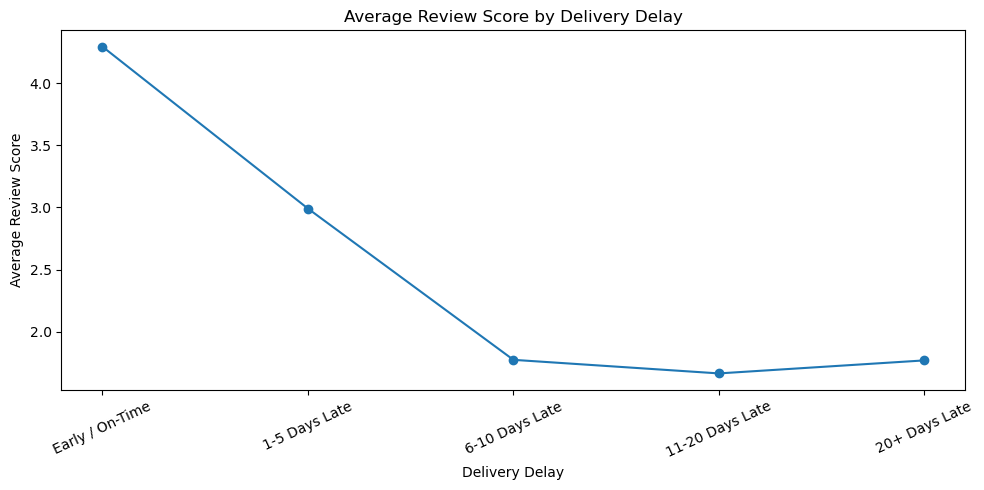

In [22]:
# BUSINESS PROBLEM 9:
# How does customer satisfaction change as delivery delay increases?

def delay_bucket(days):

    if days <= 0:
        return 'Early / On-Time'

    elif days <= 5:
        return '1-5 Days Late'

    elif days <= 10:
        return '6-10 Days Late'

    elif days <= 20:
        return '11-20 Days Late'

    else:
        return '20+ Days Late'


delivery_df['delay_bucket'] = (
    delivery_df['delivery_delay']
    .apply(delay_bucket)
)

delay_summary = (
    delivery_df
    .groupby('delay_bucket')
    .agg(
        orders=('order_id', 'nunique'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

print(delay_summary)

# A line chart helps show whether review scores decline
# as delivery delays become longer.

delay_order = [
    'Early / On-Time',
    '1-5 Days Late',
    '6-10 Days Late',
    '11-20 Days Late',
    '20+ Days Late'
]

delay_chart = (
    delay_summary
    .set_index('delay_bucket')
    .reindex(delay_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    delay_chart['delay_bucket'],
    delay_chart['avg_review'],
    marker='o'
)

plt.title(
    'Average Review Score by Delivery Delay'
)

plt.xlabel('Delivery Delay')
plt.ylabel('Average Review Score')

plt.xticks(rotation=25)
plt.tight_layout()

plt.show()

In [23]:
# BUSINESS PROBLEM 10:
# Which product categories generate the highest revenue?

category_df = df.copy()

category_summary = (
    category_df
    .groupby('Product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        items=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

category_total = category_summary['revenue'].sum()

category_summary['revenue_share'] = (
    category_summary['revenue']
    / category_total
    * 100
)

top_5_categories = (
    category_summary
    .sort_values('revenue', ascending=False)
    .head(5)
)

print(top_5_categories)
print("Total category revenue:", round(category_total, 2))

   Product_category_name_english  orders  items     revenue   avg_price  \
43                 health_beauty    8836   9991  1298554.17  129.972392   
70                 watches_gifts    5624   6209  1253504.06  201.885015   
7                 bed_bath_table    9417  11918  1101663.20   92.436919   
65                sports_leisure    7720   8971  1026677.14  114.444002   
15         computers_accessories    6689   8110   945345.51  116.565414   

    revenue_share  
43       9.247566  
70       8.926744  
7        7.845420  
65       7.311412  
15       6.732214  
Total category revenue: 14042118.74


In [24]:
# Category analysis check
category_summary_check = (
    df
    .groupby('Product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        items=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

top_10_check = category_summary_check.sort_values('revenue', ascending=False).head(10)

print(top_10_check.round(2))

   Product_category_name_english  orders  items     revenue  avg_price  \
43                 health_beauty    8836   9991  1298554.17     129.97   
70                 watches_gifts    5624   6209  1253504.06     201.89   
7                 bed_bath_table    9417  11918  1101663.20      92.44   
65                sports_leisure    7720   8971  1026677.14     114.44   
15         computers_accessories    6689   8110   945345.51     116.57   
39               furniture_decor    6449   8774   766960.62      87.41   
49                    housewares    5884   7369   668420.70      90.71   
20                    cool_stuff    3632   3992   663069.17     166.10   
5                           auto    3897   4384   617127.56     140.77   
42                  garden_tools    3518   4589   519439.33     113.19   

    avg_review  
43        4.14  
70        4.02  
7         3.89  
65        4.11  
15        3.94  
39        3.92  
49        4.06  
20        4.14  
5         4.06  
42        4.02 

In [25]:
# BUSINESS PROBLEM 11:
# Which customer states generate the highest revenue?

state_df = (
    order_df
    .groupby('customer_state')
    .agg(
        customers=('customer_unique_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('payment_value', 'sum')
    )
    .reset_index()
)

state_df['aov'] = (
    state_df['revenue']
    / state_df['orders']
)

state_total = state_df['revenue'].sum()

state_df['revenue_share'] = (
    state_df['revenue']
    / state_total
    * 100
)

top_5_states = (
    state_df
    .sort_values('revenue', ascending=False)
    .head(5)
)

print(top_5_states)
print("Total state revenue:", round(state_total, 2))

   customer_state  customers  orders     revenue         aov  revenue_share
25             SP      40302   41746  5903970.82  141.426025      37.500228
18             RJ      12384   12852  2106607.13  163.912786      13.380528
10             MG      11259   11635  1843277.32  158.425210      11.707937
22             RS       5277    5466   876412.24  160.338866       5.566704
17             PR       4882    5045   798539.73  158.283395       5.072082
Total state revenue: 15743826.42


In [26]:
# State analysis check
state_check = (
    order_df
    .groupby('customer_state')
    .agg(
        customers=('customer_unique_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('payment_value', 'sum')
    )
    .reset_index()
)

state_check['aov'] = state_check['revenue'] / state_check['orders']
state_check['revenue_share'] = state_check['revenue'] / state_check['revenue'].sum() * 100

top_10_states = state_check.sort_values('revenue', ascending=False).head(10)
print(top_10_states.round(2))
print("\nTotal revenue:", round(state_check['revenue'].sum(), 2))

   customer_state  customers  orders     revenue     aov  revenue_share
25             SP      40302   41746  5903970.82  141.43          37.50
18             RJ      12384   12852  2106607.13  163.91          13.38
10             MG      11259   11635  1843277.32  158.43          11.71
22             RS       5277    5466   876412.24  160.34           5.57
17             PR       4882    5045   798539.73  158.28           5.07
23             SC       3534    3637   612792.48  168.49           3.89
4              BA       3277    3380   602622.25  178.29           3.83
6              DF       2075    2140   348261.92  162.74           2.21
8              GO       1952    2020   344679.44  170.63           2.19
7              ES       1964    2033   321758.06  158.27           2.04

Total revenue: 15743826.42


In [27]:
# BUSINESS PROBLEM 12:
# Which sellers generate the highest revenue?

seller_summary = (
    df
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        items=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        customers=('customer_unique_id', 'nunique'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

top_sellers = (
    seller_summary
    .sort_values('revenue', ascending=False)
    .head(10)
)

print(top_sellers)

                             seller_id  orders  items    revenue  customers  \
1013  53243585a1d6dc2643021fd1853d8905     358    437  244627.55        349   
857   4869f7a5dfa277a7dca6462dcf3b52b2    1132   1186  237867.23       1124   
881   4a3ca9315b744ce9f8e9374361493884    1806   2147  215048.97       1792   
3024  fa1c13f2614d7b5c4749cbc52fecda94     585    609  203984.22        581   
1535  7c67e1448b00f6e969d365cea6b010ab     982   1459  198991.20        971   
1560  7e93a43ef30c4f03f38b393420bc753a     336    352  182878.17        336   
2643  da8622b14eb17ae2831f4ac5b9dab84a    1314   1650  170735.77       1275   
1505  7a67c85e85bb2ce8582c35f2203ad736    1160   1243  150429.81       1155   
192   1025f0e2d44d7041d6cf58b6550e0bfa     915   1465  142246.14        899   
1824  955fee9216a65b617aa5c0531780ce60    1287   1529  137360.00       1282   

       avg_price  
1013  559.788444  
857   200.562589  
881   100.162538  
3024  334.949458  
1535  136.388759  
1560  519.540256

In [28]:
# Seller analysis check
seller_check = (
    df
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        items=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean'),
        customers=('customer_unique_id', 'nunique')
    )
    .reset_index()
)

top_10_sellers = seller_check.sort_values('revenue', ascending=False).head(10)
print(top_10_sellers.round(2))

                             seller_id  orders  items    revenue  avg_price  \
1013  53243585a1d6dc2643021fd1853d8905     358    437  244627.55     559.79   
857   4869f7a5dfa277a7dca6462dcf3b52b2    1132   1186  237867.23     200.56   
881   4a3ca9315b744ce9f8e9374361493884    1806   2147  215048.97     100.16   
3024  fa1c13f2614d7b5c4749cbc52fecda94     585    609  203984.22     334.95   
1535  7c67e1448b00f6e969d365cea6b010ab     982   1459  198991.20     136.39   
1560  7e93a43ef30c4f03f38b393420bc753a     336    352  182878.17     519.54   
2643  da8622b14eb17ae2831f4ac5b9dab84a    1314   1650  170735.77     103.48   
1505  7a67c85e85bb2ce8582c35f2203ad736    1160   1243  150429.81     121.02   
192   1025f0e2d44d7041d6cf58b6550e0bfa     915   1465  142246.14      97.10   
1824  955fee9216a65b617aa5c0531780ce60    1287   1529  137360.00      89.84   

      customers  
1013        349  
857        1124  
881        1792  
3024        581  
1535        971  
1560        336  
2643

In [29]:
# BUSINESS PROBLEM 13:
# Which payment methods are most commonly used and which generate the highest revenue?

payment_df = (
    df[
        [
            'order_id',
            'payment_type',
            'payment_installments',
            'payment_value'
        ]
    ]
    .drop_duplicates('order_id')
)

# The main dataset is item-level, so duplicate payment records
# can cause the same order payment to be counted multiple times.

payment_summary = (
    payment_df
    .groupby('payment_type')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('payment_value', 'sum'),
        avg_payment=('payment_value', 'mean'),
        avg_installments=('payment_installments', 'mean')
    )
    .reset_index()
)

payment_total = payment_summary['revenue'].sum()

payment_summary['revenue_share'] = (
    payment_summary['revenue']
    / payment_total
    * 100
)

print(payment_summary)

  payment_type  orders      revenue  avg_payment  avg_installments  \
0       boleto   19784   2869361.27   145.034435          1.000000   
1  credit_card   75387  12418782.34   164.733738          3.526815   
2   debit_card    1527    217919.79   142.711061          1.000000   
3  not_defined       3         0.00     0.000000          1.000000   
4      voucher    2739    238747.26    87.165849          1.000000   

   revenue_share  
0      18.224171  
1      78.875400  
2       1.384074  
3       0.000000  
4       1.516355  


In [30]:
# Payment methods check
payment_check = (
    order_df
    .groupby('payment_type')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('payment_value', 'sum'),
        avg_payment=('payment_value', 'mean'),
        avg_installments=('payment_installments', 'mean')
    )
    .reset_index()
)

payment_check['revenue_share'] = (
    payment_check['revenue'] / payment_check['revenue'].sum() * 100
)

print(payment_check.round(2))
print("\nTotal revenue:", round(payment_check['revenue'].sum(), 2))

  payment_type  orders      revenue  avg_payment  avg_installments  \
0       boleto   19784   2869361.27       145.03              1.00   
1  credit_card   75324  12419481.81       164.88              3.53   
2   debit_card    1527    217919.79       142.71              1.00   
3  not_defined       3         0.00         0.00              1.00   
4      voucher    2802    237063.55        84.61              1.00   

   revenue_share  
0          18.23  
1          78.88  
2           1.38  
3           0.00  
4           1.51  

Total revenue: 15743826.42


In [32]:
# BUSINESS PROBLEM 14:
# Do customers who joined earlier continue purchasing in later months?

customer_first_purchase = (
    order_df
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

customer_first_purchase.rename(
    columns={
        'order_purchase_timestamp': 'first_purchase'
    },
    inplace=True
)

cohort_df = order_df.merge(
    customer_first_purchase,
    on='customer_unique_id',
    how='left'
)

cohort_df['cohort_month'] = (
    cohort_df['first_purchase']
    .dt.to_period('M')
)

cohort_df['order_month_period'] = (
    cohort_df['order_purchase_timestamp']
    .dt.to_period('M')
)

# This calculates how many months have passed since
# the customer's first purchase.

cohort_df['cohort_period'] = (
    (
        cohort_df['order_month_period'].dt.year
        - cohort_df['cohort_month'].dt.year
    ) * 12
    +
    (
        cohort_df['order_month_period'].dt.month
        - cohort_df['cohort_month'].dt.month
    )
)

cohort_table = (
    cohort_df
    .groupby(
        ['cohort_month', 'cohort_period']
    )['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_table.pivot(
    index='cohort_month',
    columns='cohort_period',
    values='customer_unique_id'
)

cohort_retention = (
    cohort_pivot
    .div(cohort_pivot.iloc[:, 0], axis=0)
    * 100
)

print(cohort_retention)

cohort_period     0           1         2         3         4         5   \
cohort_month                                                               
2016-09        100.0         NaN       NaN       NaN       NaN       NaN   
2016-10        100.0         NaN       NaN       NaN       NaN       NaN   
2016-12        100.0  100.000000       NaN       NaN       NaN       NaN   
2017-01        100.0    0.392670  0.261780  0.130890  0.392670  0.130890   
2017-02        100.0    0.228311  0.285388  0.114155  0.399543  0.114155   
2017-03        100.0    0.493171  0.379363  0.379363  0.341426  0.151745   
2017-04        100.0    0.595238  0.212585  0.170068  0.340136  0.255102   
2017-05        100.0    0.500556  0.500556  0.389321  0.305895  0.333704   
2017-06        100.0    0.477859  0.350430  0.414145  0.254858  0.382287   
2017-07        100.0    0.513611  0.359527  0.256805  0.282486  0.205444   
2017-08        100.0    0.693117  0.334608  0.262906  0.358509  0.525813   
2017-09     

In [33]:
# BUSINESS PROBLEM 15:
# Can we create one Customer 360 table containing customer
# spending, RFM segment, and churn information?

customer_360 = customer_df.merge(
    rfm[
        [
            'customer_unique_id',
            'recency',
            'frequency',
            'monetary',
            'R',
            'F',
            'M',
            'segment',
            'churn_flag'
        ]
    ],
    on='customer_unique_id',
    how='left'
)

customer_360['customer_aov'] = (
    customer_360['monetary']
    / customer_360['frequency']
)

print(customer_360.head(10))
print("Customer 360 rows:", len(customer_360))
print(
    "Unique customers:",
    customer_360['customer_unique_id'].nunique()
)

                 customer_unique_id  total_orders  total_revenue  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1         141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1          27.19   
2  0000f46a3911fa3c0805444483337064             1          86.22   
3  0000f6ccb0745a6a4b88665a16c9f078             1          43.62   
4  0004aac84e0df4da2b147fca70cf8255             1         196.89   
5  0004bd2a26a76fe21f786e4fbd80607f             1         166.98   
6  00050ab1314c0e55a6ca13cf7181fecf             1          35.38   
7  00053a61a98854899e70ed204dd4bafe             1         419.18   
8  0005e1862207bf6ccc02e4228effd9a0             1         150.12   
9  0005ef4cd20d2893f0d9fbd94d3c0d97             1         129.76   

  last_purchase first_purchase  recency  frequency  monetary  R  F  M  \
0    2018-05-10     2018-05-10      161          1    141.90  4  1  3   
1    2018-05-07     2018-05-07      164          1     27.19  4  1  1   
2    2017-03-10     2017-03-10  

In [34]:
# FINAL BUSINESS KPIs:
# What are the main business metrics of the complete analysis?

total_revenue = order_df['payment_value'].sum()

total_orders = order_df['order_id'].nunique()

total_customers = (
    order_df['customer_unique_id'].nunique()
)

aov = total_revenue / total_orders

repeat_rate = (
    (customer_df['total_orders'] > 1).sum()
    / total_customers
    * 100
)

churn_rate = (
    (rfm['churn_flag'] == 'Churned').sum()
    / total_customers
    * 100
)

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(aov, 2))
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")
print("Churn Rate:", round(churn_rate, 2), "%")
print("Late Delivery Rate:", round(late_percentage, 2), "%")

Total Revenue: 15743826.42
Total Orders: 99441
Total Customers: 96096
Average Order Value: 158.32
Repeat Customer Rate: 3.12 %
Churn Rate: 71.18 %
Late Delivery Rate: 6.66 %


In [35]:
# DATA VALIDATION:
# Are our important tables at the correct business grain?

print("Raw rows:", len(df))
print("Order-level rows:", len(order_df))
print("Unique orders:", order_df['order_id'].nunique())
print("Unique customers:", order_df['customer_unique_id'].nunique())
print("Customer 360 rows:", len(customer_360))
print("RFM rows:", len(rfm))

print("\nRFM segment counts:")
print(rfm['segment'].value_counts())

# These checks confirm that each analytical table has
# one row per expected business entity.

assert len(order_df) == order_df['order_id'].nunique()

assert (
    len(customer_df)
    == customer_df['customer_unique_id'].nunique()
)

assert (
    len(rfm)
    == rfm['customer_unique_id'].nunique()
)

print("\nAll basic grain checks passed.")

Raw rows: 118763
Order-level rows: 99441
Unique orders: 99441
Unique customers: 96096
Customer 360 rows: 96096
RFM rows: 96096

RFM segment counts:
segment
Loyal Customers    29749
At-Risk            24045
Regular            17825
Cant Lose          11970
Champions           6308
Hibernating         6199
Name: count, dtype: int64

All basic grain checks passed.


In [36]:
# ============================================================

import os

export_path = r'C:\Users\moham\Ecommerce_Customer_360_Analytics\03_Final_Data'

if not os.path.exists(export_path):
    os.makedirs(export_path)

# ------------------------------------------------------------
# 1. customer_360_master.csv
# ------------------------------------------------------------
# Power BI ke liye churn flag numeric bana do
customer_360['churn_flag_num'] = customer_360['churn_flag'].map({
    'Churned': 1,
    'Active': 0
})

customer_360.to_csv(
    os.path.join(export_path, 'customer_360_master.csv'),
    index=False
)

print("customer_360_master.csv saved")
print("  Rows:", len(customer_360))
print("  Columns:", customer_360.columns.tolist())

# ------------------------------------------------------------
# 2. transactions_cleaned.csv
# ------------------------------------------------------------
order_df.to_csv(
    os.path.join(export_path, 'transactions_cleaned.csv'),
    index=False
)

print("\ntransactions_cleaned.csv saved")
print("  Rows:", len(order_df))


# Monthly sales
monthly_sales.to_csv(
    os.path.join(export_path, 'monthly_sales.csv'),
    index=False
)

# Segment summary
segment_aov.to_csv(
    os.path.join(export_path, 'segment_summary.csv'),
    index=False
)

# Category summary
category_summary.to_csv(
    os.path.join(export_path, 'category_summary.csv'),
    index=False
)

# State summary
state_df.to_csv(
    os.path.join(export_path, 'state_summary.csv'),
    index=False
)

# Seller summary
seller_summary.to_csv(
    os.path.join(export_path, 'seller_summary.csv'),
    index=False
)

# Payment summary
payment_summary.to_csv(
    os.path.join(export_path, 'payment_summary.csv'),
    index=False
)

# Cohort retention
cohort_retention.to_csv(
    os.path.join(export_path, 'cohort_retention.csv')
)

print("\nAll files overwritten successfully.")
print("Location:", export_path)

customer_360_master.csv saved
  Rows: 96096
  Columns: ['customer_unique_id', 'total_orders', 'total_revenue', 'last_purchase', 'first_purchase', 'recency', 'frequency', 'monetary', 'R', 'F', 'M', 'segment', 'churn_flag', 'customer_aov', 'churn_flag_num']

transactions_cleaned.csv saved
  Rows: 99441

All files overwritten successfully.
Location: C:\Users\moham\Ecommerce_Customer_360_Analytics\03_Final_Data
